# Question 1: Search Algorithms — The Warehouse Logistics Bot

## Overview
This notebook implements two informed search algorithms to navigate an 
Automated Guided Vehicle (AGV) through a warehouse grid:

- **Greedy Best-First Search**: Uses only h(n) — the Euclidean distance 
  to the goal — as priority. Fast but not guaranteed to find the shortest path.
- **A\* Search**: Uses f(n) = g(n) + h(n), balancing actual path cost with 
  the estimated remaining cost. Guaranteed to find the optimal path.

### Heuristic Used
`h(n) = √((x1 - x2)² + (y1 - y2)²)`

This is **admissible** — it never overestimates the true cost — which 
guarantees A* always finds the optimal path.

## Node Class
Each node represents one position the robot visits during the search.
It stores:
- `state`: current (row, col) position on the grid
- `parent`: the node we came from (so we can trace the path back to A)
- `action`: the direction taken to reach this node (up/down/left/right)
- `g`: total path cost from start A — i.e. how many steps taken so far

In [4]:
import heapq
import math
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

In [5]:
class Node:
    """Represents a single state in the search tree."""

    def __init__(self, state, parent=None, action=None, g=0):
        self.state = state      # (row, col)
        self.parent = parent    # parent Node
        self.action = action    # direction taken to reach this node
        self.g = g              # path cost from start (steps taken)

    def __lt__(self, other):
        """Needed by heapq when two priorities are equal."""
        return self.g < other.g

## Warehouse Class
The `Warehouse` class is the brain of the program. It:
1. Reads the `.txt` file and builds the grid in memory
2. Finds where **A** (Charging Station) and **B** (Product Bin) are
3. Remembers which cells are walls/shelves
4. Has a `neighbors()` method to find valid moves from any position
5. Has a `solve()` method that runs either Greedy or A* search
6. Has a `visualize()` method that draws and saves the result image

In [6]:
class Warehouse:
    """Models the warehouse grid environment."""

    def __init__(self, filename):
        self.grid = []
        self.start = None
        self.goal = None
        self.walls = set()
        self.solution = []
        self.explored_states = set()

        # Read the .txt file line by line
        with open(filename) as f:
            lines = f.readlines()

        # Loop through every character in every line
        for r, line in enumerate(lines):
            row = []
            for c, ch in enumerate(line.rstrip('\n')):
                row.append(ch)
                if ch == 'A':
                    self.start = (r, c)
                elif ch == 'B':
                    self.goal = (r, c)
                elif ch == '#':
                    self.walls.add((r, c))
            self.grid.append(row)

        self.rows = len(self.grid)
        self.cols = max(len(row) for row in self.grid)

        if self.start is None or self.goal is None:
            raise ValueError("Warehouse file must contain 'A' and 'B'.")

        print(f"Warehouse loaded: {self.rows} rows x {self.cols} cols")
        print(f"Start (A): {self.start}  |  Goal (B): {self.goal}")
        print(f"Total wall cells: {len(self.walls)}")

    # --- Heuristic: Euclidean distance to goal ---
    def heuristic(self, state):
        x1, y1 = state
        x2, y2 = self.goal
        return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)

    # --- Neighbors: valid adjacent non-wall cells ---
    def neighbors(self, state):
        r, c = state
        candidates = [
            ("up",    r - 1, c),
            ("down",  r + 1, c),
            ("left",  r,     c - 1),
            ("right", r,     c + 1),
        ]
        valid = []
        for action, nr, nc in candidates:
            if 0 <= nr < self.rows and 0 <= nc < self.cols:
                if (nr, nc) not in self.walls:
                    valid.append((action, (nr, nc)))
        return valid

    # --- Solve: Greedy or A* ---
    def solve(self, algorithm="astar"):
        self.solution = []
        self.explored_states = set()

        start_node = Node(state=self.start, g=0)
        h_start = self.heuristic(self.start)
        priority = h_start if algorithm == "greedy" else 0 + h_start

        frontier = [(priority, start_node)]
        heapq.heapify(frontier)

        explored = set()
        nodes_expanded = 0

        while frontier:
            _, current = heapq.heappop(frontier)

            if current.state == self.goal:
                path = []
                node = current
                while node.parent is not None:
                    path.append((node.action, node.state))
                    node = node.parent
                path.reverse()
                self.solution = path
                print(f"\n[{algorithm.upper()}] Solution found!")
                print(f"  Path length     : {len(path)} steps")
                print(f"  Nodes expanded  : {nodes_expanded}")
                print(f"  States explored : {len(self.explored_states)}")
                return path

            if current.state in explored:
                continue

            explored.add(current.state)
            self.explored_states.add(current.state)
            nodes_expanded += 1

            for action, next_state in self.neighbors(current.state):
                if next_state not in explored:
                    g_new = current.g + 1
                    h_new = self.heuristic(next_state)
                    p = h_new if algorithm == "greedy" else g_new + h_new

                    child = Node(
                        state=next_state,
                        parent=current,
                        action=action,
                        g=g_new
                    )
                    heapq.heappush(frontier, (p, child))

        print(f"[{algorithm.upper()}] No solution found.")
        return None

    # --- Visualize: export image ---
    def visualize(self, title="Warehouse Path", filename="warehouse_path.png"):
        path_states = set(state for _, state in self.solution)

        fig, ax = plt.subplots(figsize=(self.cols * 0.6, self.rows * 0.6))
        fig.patch.set_facecolor('#1a1a2e')

        for r in range(self.rows):
            for c in range(self.cols):
                cell = (r, c)

                if cell in self.walls:
                    color = '#2d2d2d'
                elif cell == self.start:
                    color = '#00cc44'
                elif cell == self.goal:
                    color = '#ff4444'
                elif cell in path_states:
                    color = '#FFD700'
                elif cell in self.explored_states:
                    color = '#5b9bd5'
                else:
                    color = '#f0f0f0'

                rect = plt.Rectangle(
                    (c, self.rows - r - 1), 1, 1,
                    color=color, ec='#555555', lw=0.4
                )
                ax.add_patch(rect)

                if cell == self.start:
                    ax.text(c + 0.5, self.rows - r - 0.5, 'A',
                            ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')
                elif cell == self.goal:
                    ax.text(c + 0.5, self.rows - r - 0.5, 'B',
                            ha='center', va='center',
                            fontsize=9, fontweight='bold', color='white')

        legend_items = [
            mpatches.Patch(color='#2d2d2d', label='Wall / Shelf'),
            mpatches.Patch(color='#00cc44', label='Start (A)'),
            mpatches.Patch(color='#ff4444', label='Goal (B)'),
            mpatches.Patch(color='#FFD700', label='Optimal Path'),
            mpatches.Patch(color='#5b9bd5', label='Explored (not on path)'),
            mpatches.Patch(color='#f0f0f0', label='Open Aisle'),
        ]
        ax.legend(handles=legend_items, loc='upper right', fontsize=7,
                  facecolor='#1a1a2e', labelcolor='white', framealpha=0.8)

        ax.set_xlim(0, self.cols)
        ax.set_ylim(0, self.rows)
        ax.set_aspect('equal')
        ax.set_title(title, fontsize=13, fontweight='bold',
                     color='white', pad=10)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig(filename, dpi=150, bbox_inches='tight',
                    facecolor=fig.get_facecolor())
        plt.show()
        print(f"Saved: {filename}\n")

## Results — Small Warehouse
A simple 10×5 grid. Good baseline to verify both algorithms work correctly.

SMALL WAREHOUSE
Warehouse loaded: 5 rows x 10 cols
Start (A): (1, 1)  |  Goal (B): (3, 7)
Total wall cells: 32

[GREEDY] Solution found!
  Path length     : 10 steps
  Nodes expanded  : 10
  States explored : 10


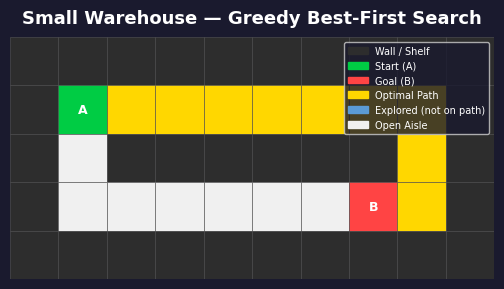

Saved: small_greedy.png

Warehouse loaded: 5 rows x 10 cols
Start (A): (1, 1)  |  Goal (B): (3, 7)
Total wall cells: 32

[ASTAR] Solution found!
  Path length     : 8 steps
  Nodes expanded  : 14
  States explored : 14


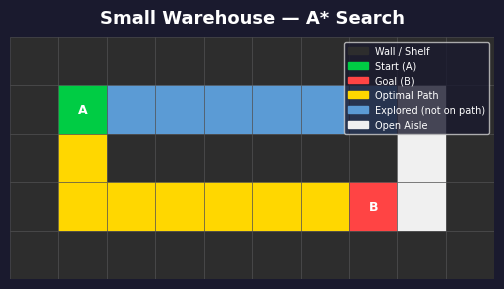

Saved: small_astar.png



In [7]:
print("=" * 50)
print("SMALL WAREHOUSE")
print("=" * 50)

w_small_greedy = Warehouse("warehouse_small.txt")
path_sg = w_small_greedy.solve(algorithm="greedy")
w_small_greedy.visualize(
    title="Small Warehouse — Greedy Best-First Search",
    filename="small_greedy.png"
)

w_small_astar = Warehouse("warehouse_small.txt")
path_sa = w_small_astar.solve(algorithm="astar")
w_small_astar.visualize(
    title="Small Warehouse — A* Search",
    filename="small_astar.png"
)

## Results — Medium Warehouse
A 16×8 grid with more complex corridors.

MEDIUM WAREHOUSE
Warehouse loaded: 9 rows x 16 cols
Start (A): (1, 1)  |  Goal (B): (7, 13)
Total wall cells: 82

[GREEDY] Solution found!
  Path length     : 20 steps
  Nodes expanded  : 37
  States explored : 37


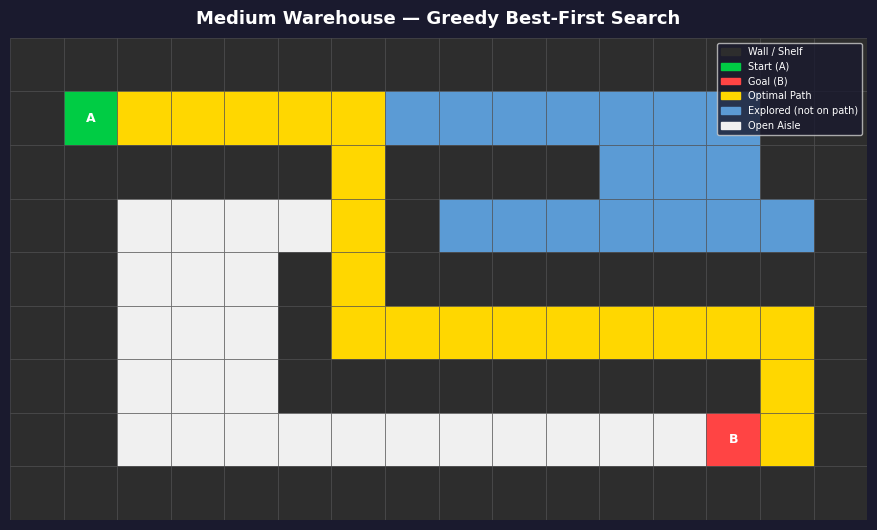

Saved: medium_greedy.png

Warehouse loaded: 9 rows x 16 cols
Start (A): (1, 1)  |  Goal (B): (7, 13)
Total wall cells: 82

[ASTAR] Solution found!
  Path length     : 20 steps
  Nodes expanded  : 39
  States explored : 39


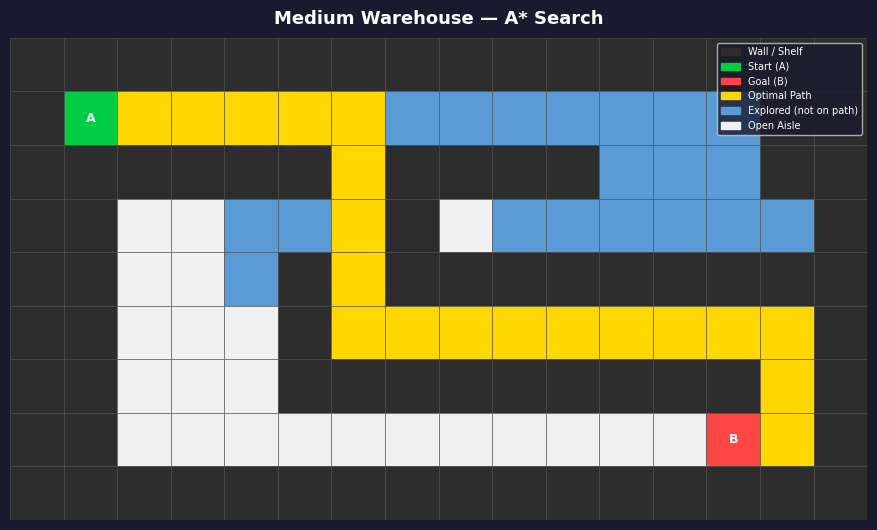

Saved: medium_astar.png



In [8]:
print("=" * 50)
print("MEDIUM WAREHOUSE")
print("=" * 50)

w_med_greedy = Warehouse("warehouse_medium.txt")
path_mg = w_med_greedy.solve(algorithm="greedy")
w_med_greedy.visualize(
    title="Medium Warehouse — Greedy Best-First Search",
    filename="medium_greedy.png"
)

w_med_astar = Warehouse("warehouse_medium.txt")
path_ma = w_med_astar.solve(algorithm="astar")
w_med_astar.visualize(
    title="Medium Warehouse — A* Search",
    filename="medium_astar.png"
)

## Results — Hard Warehouse
A 20×10 grid with dense shelving. This is where the difference between
Greedy and A* is most visible.

HARD WAREHOUSE
Warehouse loaded: 11 rows x 20 cols
Start (A): (1, 1)  |  Goal (B): (9, 18)
Total wall cells: 125

[GREEDY] Solution found!
  Path length     : 45 steps
  Nodes expanded  : 47
  States explored : 47


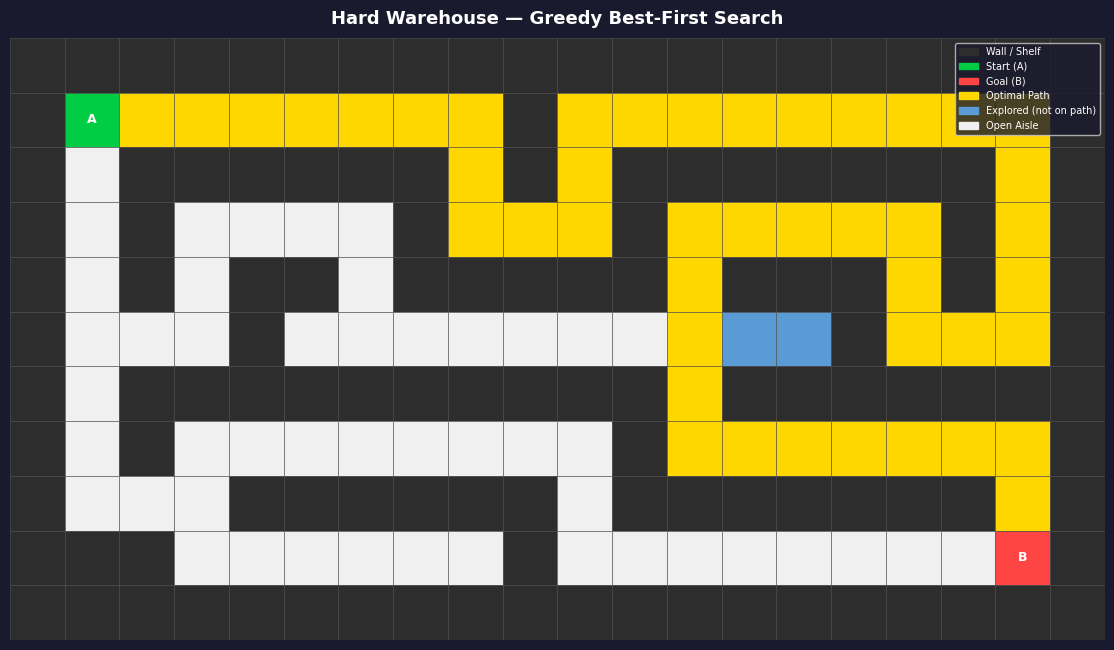

Saved: hard_greedy.png

Warehouse loaded: 11 rows x 20 cols
Start (A): (1, 1)  |  Goal (B): (9, 18)
Total wall cells: 125

[ASTAR] Solution found!
  Path length     : 27 steps
  Nodes expanded  : 69
  States explored : 69


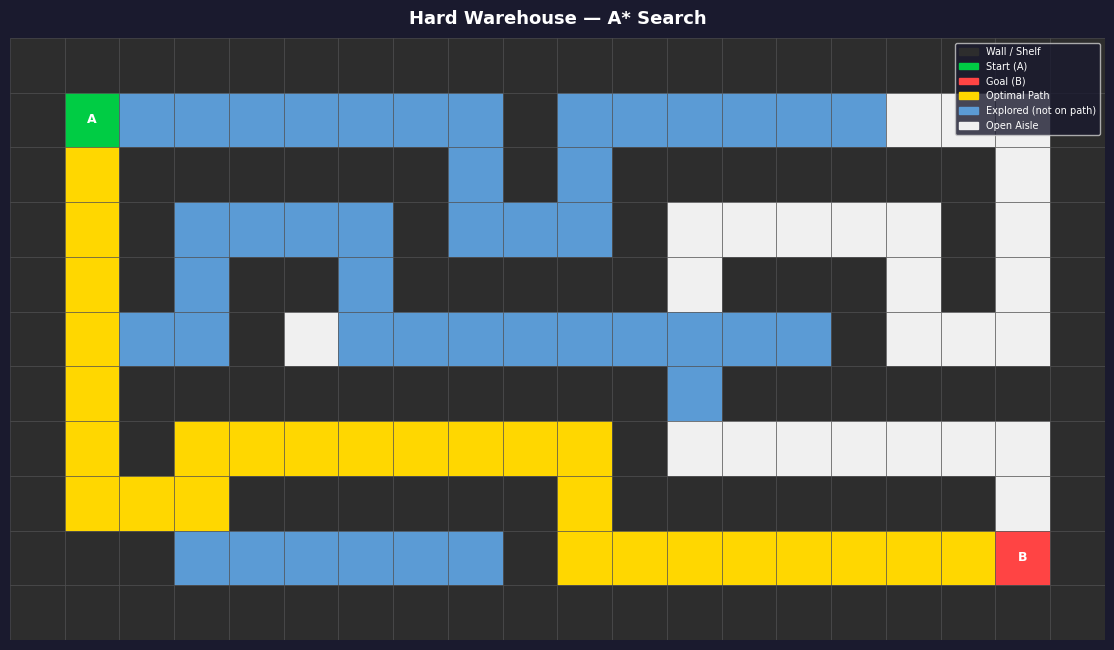

Saved: hard_astar.png



In [9]:
print("=" * 50)
print("HARD WAREHOUSE")
print("=" * 50)

w_hard_greedy = Warehouse("warehouse_hard.txt")
path_hg = w_hard_greedy.solve(algorithm="greedy")
w_hard_greedy.visualize(
    title="Hard Warehouse — Greedy Best-First Search",
    filename="hard_greedy.png"
)

w_hard_astar = Warehouse("warehouse_hard.txt")
path_ha = w_hard_astar.solve(algorithm="astar")
w_hard_astar.visualize(
    title="Hard Warehouse — A* Search",
    filename="hard_astar.png"
)

## Algorithm Comparison & Conclusion
The table below compares both algorithms across all three warehouse sizes.

In [10]:
print("=" * 62)
print(f"{'WAREHOUSE':<12} {'ALGORITHM':<10} {'PATH LEN':>10} {'EXPLORED':>12}")
print("=" * 62)

results = [
    ("Small",  "Greedy", path_sg, w_small_greedy),
    ("Small",  "A*",     path_sa, w_small_astar),
    ("Medium", "Greedy", path_mg, w_med_greedy),
    ("Medium", "A*",     path_ma, w_med_astar),
    ("Hard",   "Greedy", path_hg, w_hard_greedy),
    ("Hard",   "A*",     path_ha, w_hard_astar),
]

for name, algo, path, w in results:
    plen = len(path) if path else "N/A"
    expl = len(w.explored_states)
    print(f"{name:<12} {algo:<10} {str(plen):>10} {expl:>12}")

print("=" * 62)

WAREHOUSE    ALGORITHM    PATH LEN     EXPLORED
Small        Greedy             10           10
Small        A*                  8           14
Medium       Greedy             20           37
Medium       A*                 20           39
Hard         Greedy             45           47
Hard         A*                 27           69


## Conclusion

- **A\*** always finds the **shortest possible path** because the Euclidean 
  distance heuristic is admissible — it never overestimates the true cost.
- **Greedy** can be faster in simple cases but may find longer paths because 
  it only looks ahead (h(n)) and ignores how far it has already travelled (g(n)).
- The hard warehouse demonstrates this most clearly — winding shelves 
  mislead Greedy while A* still finds the true optimal route.